<a href="https://colab.research.google.com/github/Mohommad-Nuzlan-GH/M-R-M-Nuzlan-Database-Analytics-Top-Up-2026/blob/main/3_R_Analytics_NS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install required R packages
install.packages("ggplot2")
install.packages("dplyr")

# 2. Load required R packages
library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# Load cleaned datasets into R
CUSTOMER <- read.csv("1#clean_customers.csv")
APP_EVENT <- read.csv("2#clean_app_events.csv")
ORDER_DATA <- read.csv("3#clean_orders.csv")
COMPLAINT <- read.csv("4#clean_complaints.csv")
DELIVERY <- read.csv("5#clean_deliveries.csv")
DRIVER <- read.csv("6#clean_drivers.csv")
VEHICLE <- read.csv("7#clean_vehicles.csv")
HUB <- read.csv("8#clean_hubs.csv")
INCIDENT <- read.csv("9#clean_incidents.csv")

In [3]:
# Check main datasets
head(DELIVERY)
head(COMPLAINT)
head(HUB)

# Check dataset structures
str(DELIVERY)
str(COMPLAINT)
str(HUB)

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours,failed_delivery_flag,delayed_delivery_flag
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2026-04-28 05:59:54,Failed,17.26,1,0,3.07,12.05,16291.05,1,0
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,,Ontime,10.34,1,0,5.00,13.41,NA,0,0
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,,Ontime,7.92,0,0,4.98,8.51,NA,0,0
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,,Delayed,16.42,0,0,4.18,13.62,NA,0,1
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,,Ontime,14.52,1,0,4.18,9.22,NA,0,0
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2026-04-28 11:52:24,Delayed,13.84,0,0,1.57,9.58,14255.21,0,1


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount,is_resolved
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>
1,CP0001,C0464,O00814,Appissue,App,High,2025-03-30 02:36:00,Open,11,23.99,0
2,CP0002,C0056,O00628,Missedpickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64,0
3,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41,0
4,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,Awaitingcustomer,7,23.44,0
5,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18,1
6,CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51,1


,hub_id,hub_name,zone,hub_type,capacity_score,capacity_category
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,H01,North Exchange,North,Dispatch,82,High
2,H02,South Link,South,Dispatch,78,High
3,H03,East Dock,East,Warehouse,74,Medium
4,H04,West Gate,West,Dispatch,69,Medium
5,H05,Central Core,Central,Control,88,High
6,H06,Airport Hub,Airport,Dispatch,71,Medium


'data.frame':	950 obs. of  16 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr  "O00938" "O00004" "O00639" "O00313" ...
 $ driver_id                    : chr  "D004" "D138" "D006" "D116" ...
 $ vehicle_id                   : chr  "V056" "V007" "V049" "V055" ...
 $ hub_id                       : chr  "H05" "H02" "H02" "H02" ...
 $ dispatch_time                : chr  "2024-06-18 10:57:00" "2025-01-11 18:45:00" "2025-06-02 20:39:00" "2024-03-08 23:31:00" ...
 $ delivery_completed_at        : chr  "2026-04-28 05:59:54" "" "" "" ...
 $ delivery_status              : chr  "Failed" "Ontime" "Ontime" "Delayed" ...
 $ route_distance_km            : num  17.26 10.34 7.92 16.42 14.52 ...
 $ manual_route_override_count  : int  1 1 0 0 1 0 0 1 1 1 ...
 $ proof_of_completion_missing  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ customer_rating_post_delivery: num  3.07 5 4.98 4.18 4.18 1.57 4.64 3.76 3.7 3.2 ...
 $ fuel_or_charge

In [4]:
#-------------GRAPHS TO BE CREATED---------------------

# GRAPH 1: Delivery Status Distribution
# GRAPH 2: Hub Performance - Delayed Deliveries
# GRAPH 3: Hub Performance - Failed Deliveries
# GRAPH 4: Complaints by Type
# GRAPH 5: Complaints by Severity
# GRAPH 6: Delivery Status vs Complaints
# GRAPH 7: Driver Performance - Top Problem Drivers
# GRAPH 8: Vehicle Condition vs Delivery Failures
# GRAPH 9: Hub Volume vs Complaints
# GRAPH 10: Incident Severity vs Delivery Status

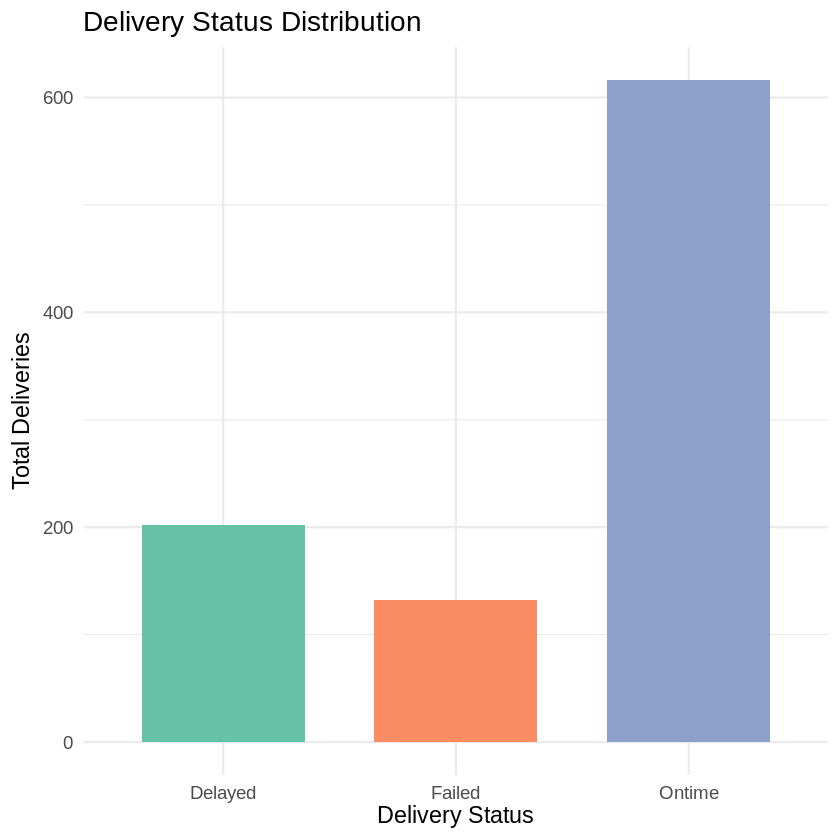

In [6]:
#-------------GRAPH 1: DELIVERY STATUS DISTRIBUTION---------------------

delivery_status_count <- DELIVERY %>%
  group_by(delivery_status) %>%
  summarise(total_deliveries = n())

ggplot(delivery_status_count, aes(x = delivery_status, y = total_deliveries, fill = delivery_status)) +
  geom_bar(stat = "identity", width = 0.7) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Total Deliveries"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

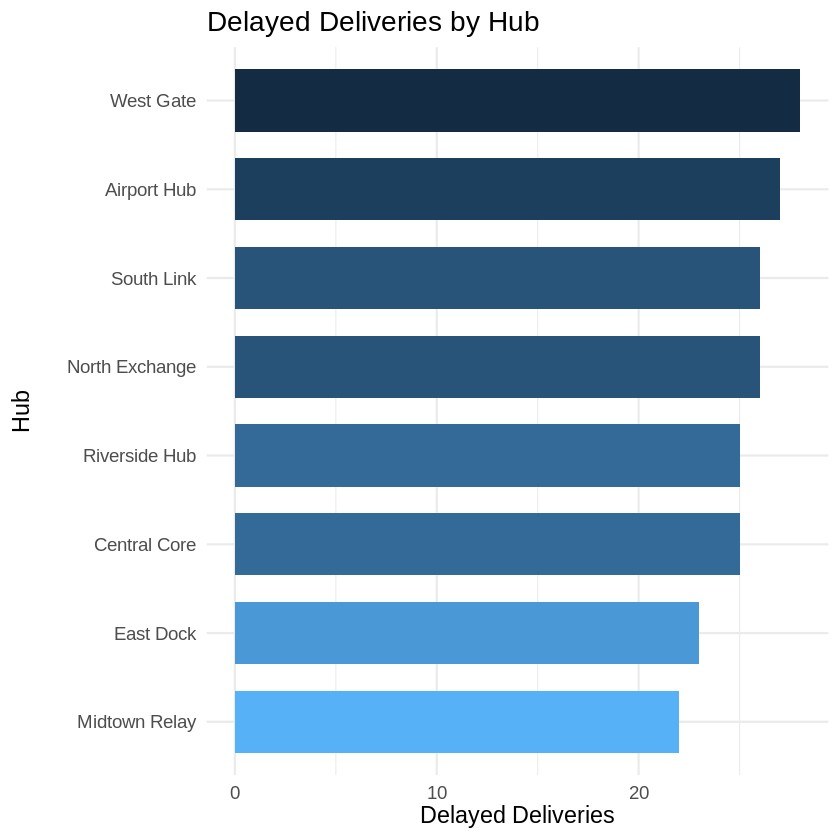

In [5]:
#-------------GRAPH 2: HUB PERFORMANCE - DELAYED DELIVERIES---------------------

hub_delays <- DELIVERY %>%
  inner_join(HUB, by = "hub_id") %>%
  filter(delivery_status == "Delayed") %>%
  group_by(hub_name) %>%
  summarise(delayed_deliveries = n()) %>%
  arrange(desc(delayed_deliveries))

ggplot(hub_delays, aes(x = reorder(hub_name, delayed_deliveries), y = delayed_deliveries, fill = delayed_deliveries)) +
  geom_bar(stat = "identity", width = 0.7) +
  coord_flip() +
  scale_fill_gradient(low = "#56B1F7", high = "#132B43") +
  labs(
    title = "Delayed Deliveries by Hub",
    x = "Hub",
    y = "Delayed Deliveries"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

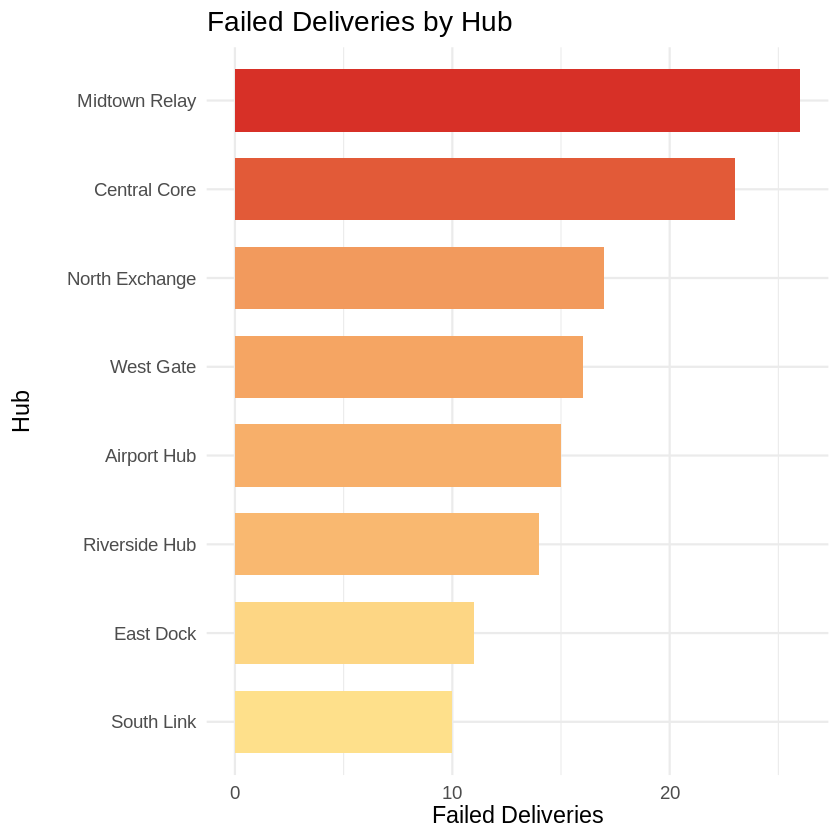

In [7]:
#-------------GRAPH 3: HUB PERFORMANCE - FAILED DELIVERIES---------------------

hub_failures <- DELIVERY %>%
  inner_join(HUB, by = "hub_id") %>%
  filter(delivery_status == "Failed") %>%
  group_by(hub_name) %>%
  summarise(failed_deliveries = n()) %>%
  arrange(desc(failed_deliveries))

ggplot(hub_failures, aes(x = reorder(hub_name, failed_deliveries), y = failed_deliveries, fill = failed_deliveries)) +
  geom_bar(stat = "identity", width = 0.7) +
  coord_flip() +
  scale_fill_gradient(low = "#FEE08B", high = "#D73027") +
  labs(
    title = "Failed Deliveries by Hub",
    x = "Hub",
    y = "Failed Deliveries"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

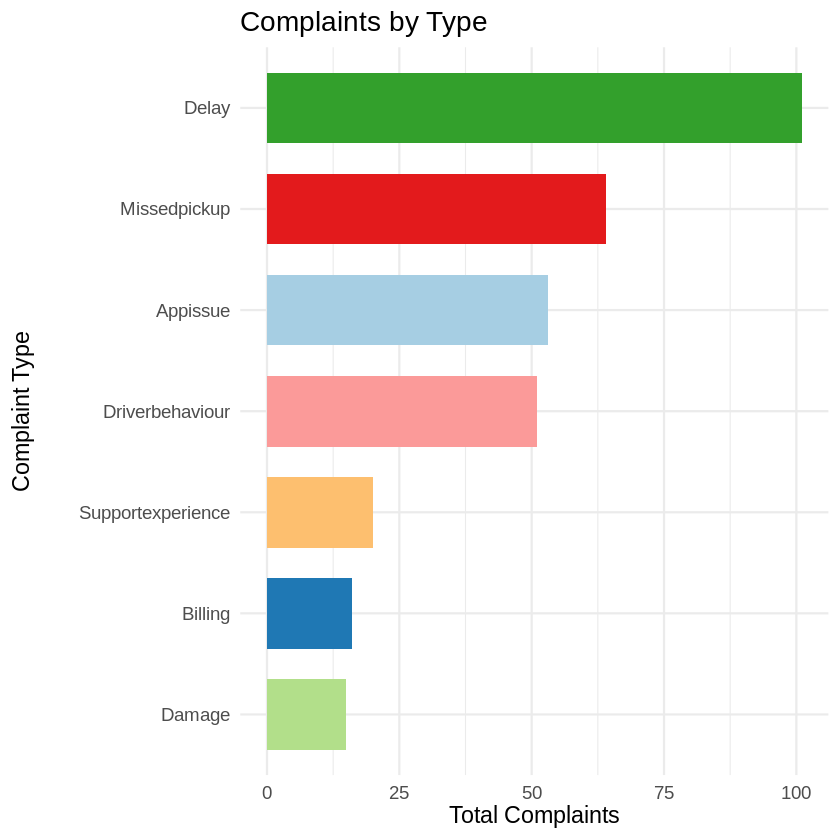

In [8]:
#-------------GRAPH 4: COMPLAINTS BY TYPE---------------------

complaints_type <- COMPLAINT %>%
  group_by(complaint_type) %>%
  summarise(total_complaints = n()) %>%
  arrange(desc(total_complaints))

ggplot(complaints_type, aes(x = reorder(complaint_type, total_complaints), y = total_complaints, fill = complaint_type)) +
  geom_bar(stat = "identity", width = 0.7) +
  coord_flip() +
  scale_fill_brewer(palette = "Paired") +
  labs(
    title = "Complaints by Type",
    x = "Complaint Type",
    y = "Total Complaints"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

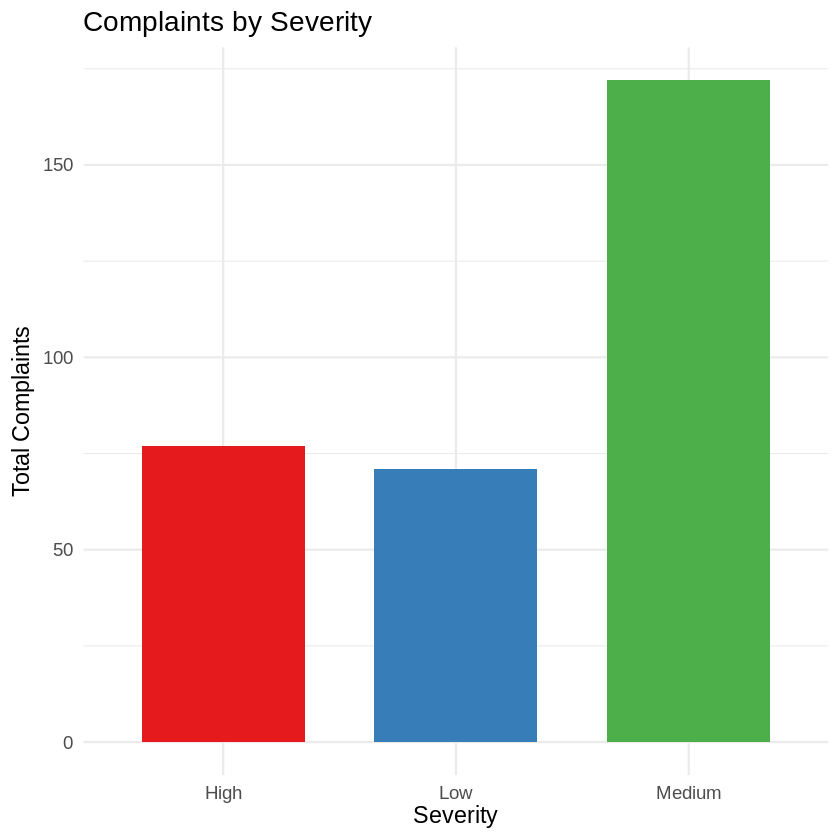

In [9]:
#-------------GRAPH 5: COMPLAINTS BY SEVERITY---------------------

complaints_severity <- COMPLAINT %>%
  group_by(severity) %>%
  summarise(total_complaints = n()) %>%
  arrange(desc(total_complaints))

ggplot(complaints_severity, aes(x = severity, y = total_complaints, fill = severity)) +
  geom_bar(stat = "identity", width = 0.7) +
  scale_fill_brewer(palette = "Set1") +
  labs(
    title = "Complaints by Severity",
    x = "Severity",
    y = "Total Complaints"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

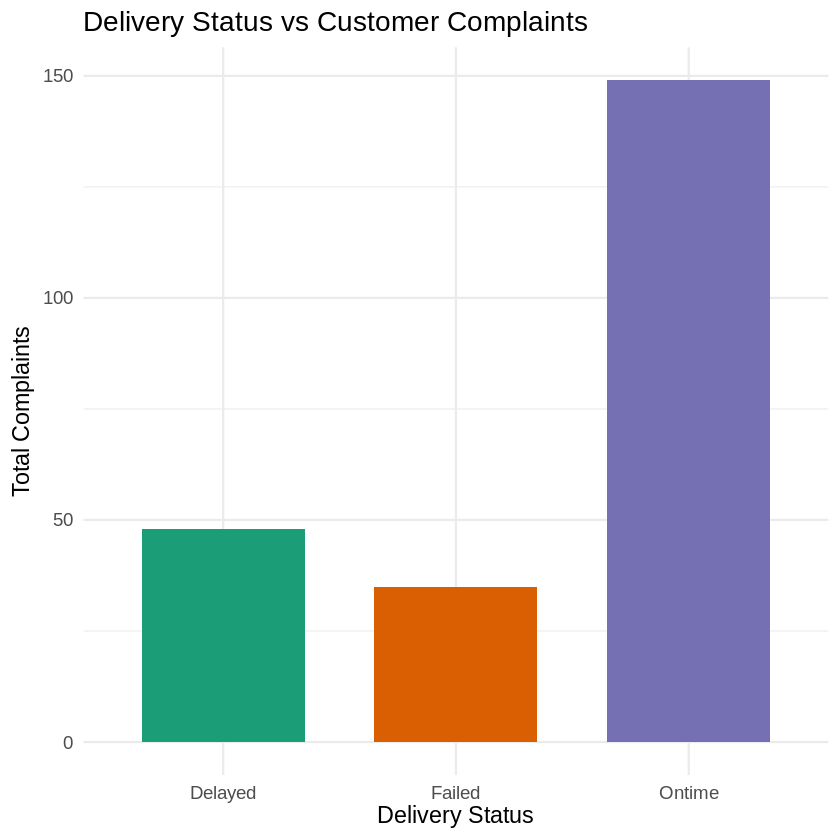

In [10]:
#-------------GRAPH 6: DELIVERY STATUS VS COMPLAINTS---------------------

delivery_complaints <- DELIVERY %>%
  left_join(ORDER_DATA, by = "order_id") %>%
  left_join(COMPLAINT, by = "order_id") %>%
  group_by(delivery_status) %>%
  summarise(total_complaints = sum(!is.na(complaint_id)))

ggplot(delivery_complaints, aes(x = delivery_status, y = total_complaints, fill = delivery_status)) +
  geom_bar(stat = "identity", width = 0.7) +
  scale_fill_brewer(palette = "Dark2") +
  labs(
    title = "Delivery Status vs Customer Complaints",
    x = "Delivery Status",
    y = "Total Complaints"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

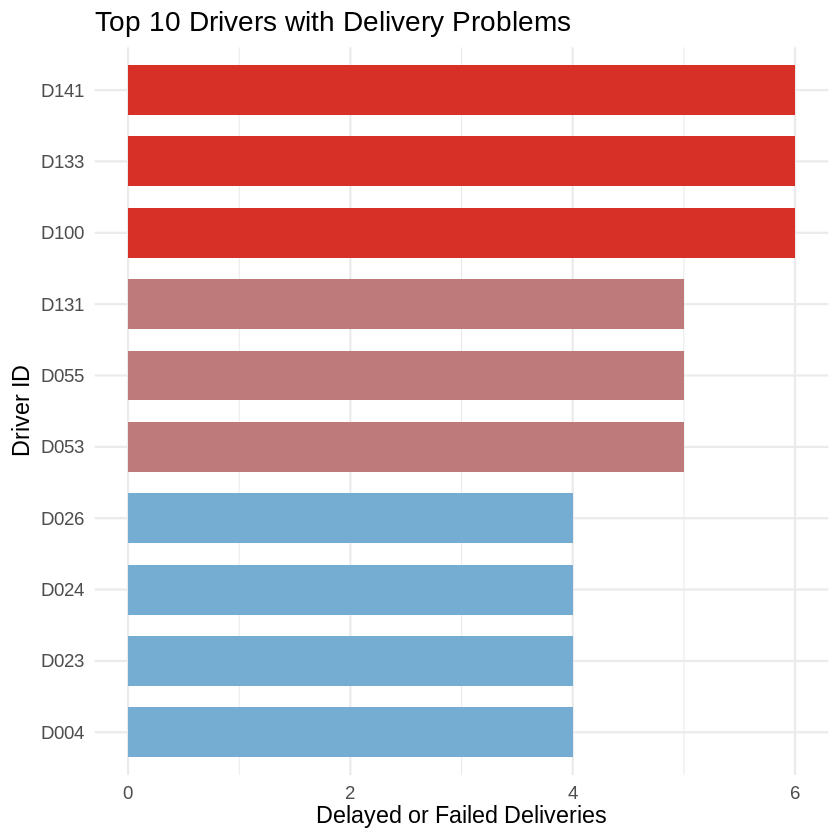

In [11]:
#-------------GRAPH 7: DRIVER PERFORMANCE - TOP PROBLEM DRIVERS---------------------

driver_problems <- DELIVERY %>%
  filter(delivery_status %in% c("Delayed", "Failed")) %>%
  group_by(driver_id) %>%
  summarise(problem_deliveries = n()) %>%
  arrange(desc(problem_deliveries)) %>%
  head(10)

ggplot(driver_problems, aes(x = reorder(driver_id, problem_deliveries), y = problem_deliveries, fill = problem_deliveries)) +
  geom_bar(stat = "identity", width = 0.7) +
  coord_flip() +
  scale_fill_gradient(low = "#74ADD1", high = "#D73027") +
  labs(
    title = "Top 10 Drivers with Delivery Problems",
    x = "Driver ID",
    y = "Delayed or Failed Deliveries"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

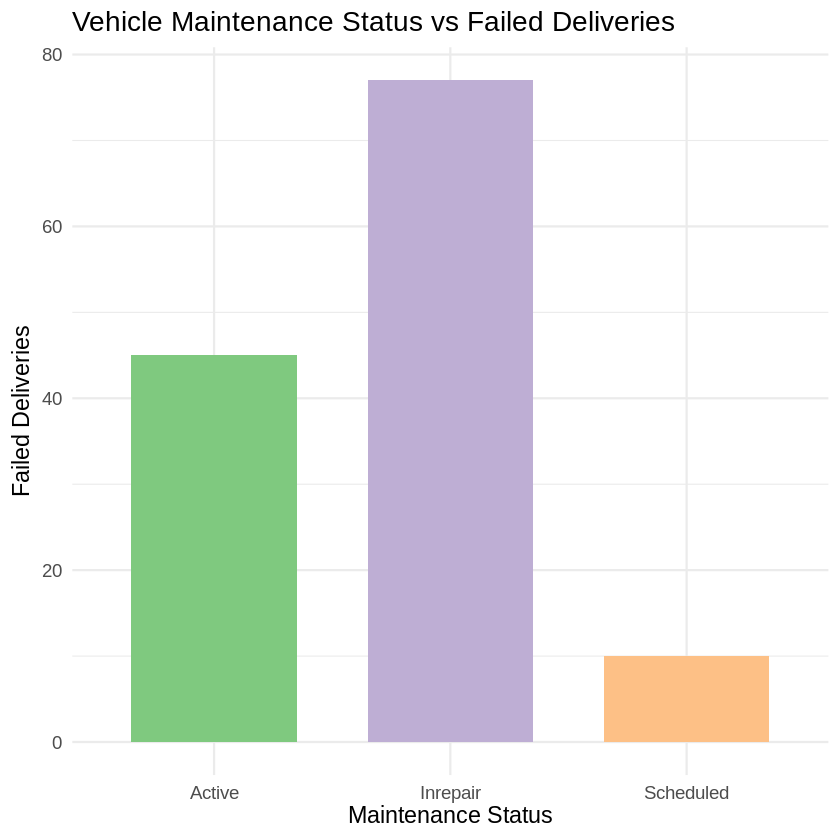

In [12]:
#-------------GRAPH 8: VEHICLE CONDITION VS DELIVERY FAILURES---------------------

vehicle_failures <- DELIVERY %>%
  inner_join(VEHICLE, by = "vehicle_id") %>%
  filter(delivery_status == "Failed") %>%
  group_by(maintenance_status) %>%
  summarise(failed_deliveries = n()) %>%
  arrange(desc(failed_deliveries))

ggplot(vehicle_failures, aes(x = maintenance_status, y = failed_deliveries, fill = maintenance_status)) +
  geom_bar(stat = "identity", width = 0.7) +
  scale_fill_brewer(palette = "Accent") +
  labs(
    title = "Vehicle Maintenance Status vs Failed Deliveries",
    x = "Maintenance Status",
    y = "Failed Deliveries"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

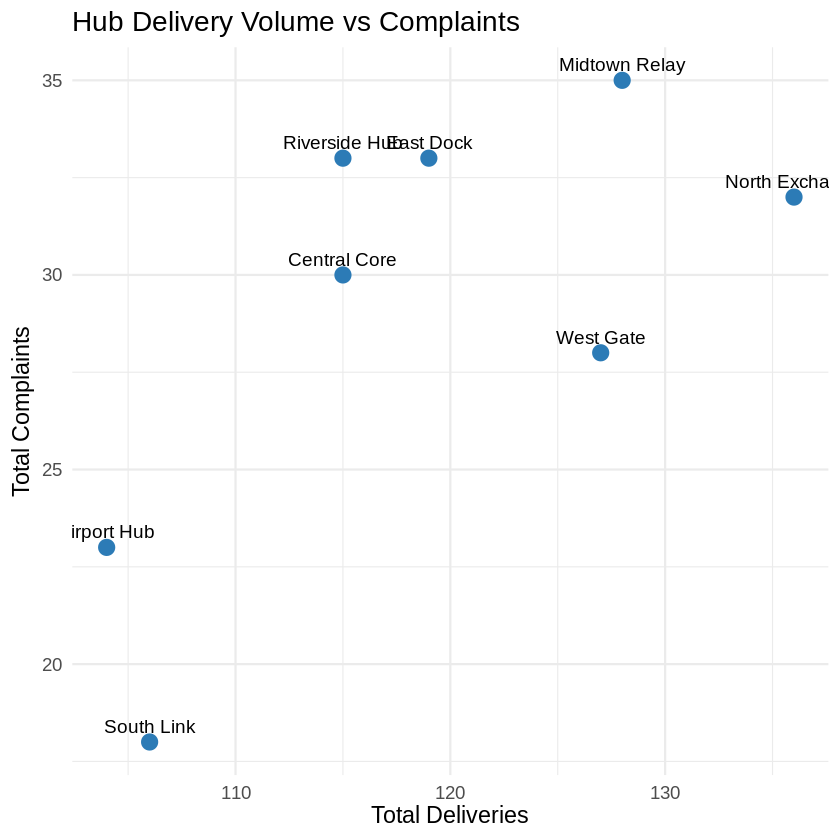

In [13]:
#-------------GRAPH 9: HUB VOLUME VS COMPLAINTS---------------------

hub_volume_complaints <- HUB %>%
  left_join(DELIVERY, by = "hub_id") %>%
  left_join(ORDER_DATA, by = "order_id") %>%
  left_join(COMPLAINT, by = "order_id") %>%
  group_by(hub_name) %>%
  summarise(
    total_deliveries = n_distinct(delivery_id),
    total_complaints = sum(!is.na(complaint_id))
  )

ggplot(hub_volume_complaints, aes(x = total_deliveries, y = total_complaints)) +
  geom_point(size = 4, color = "#2C7BB6") +
  geom_text(aes(label = hub_name), vjust = -0.7, size = 4) +
  labs(
    title = "Hub Delivery Volume vs Complaints",
    x = "Total Deliveries",
    y = "Total Complaints"
  ) +
  theme_minimal(base_size = 14)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by delivery_status and severity.
ℹ Output is grouped by delivery_status.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(delivery_status, severity))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


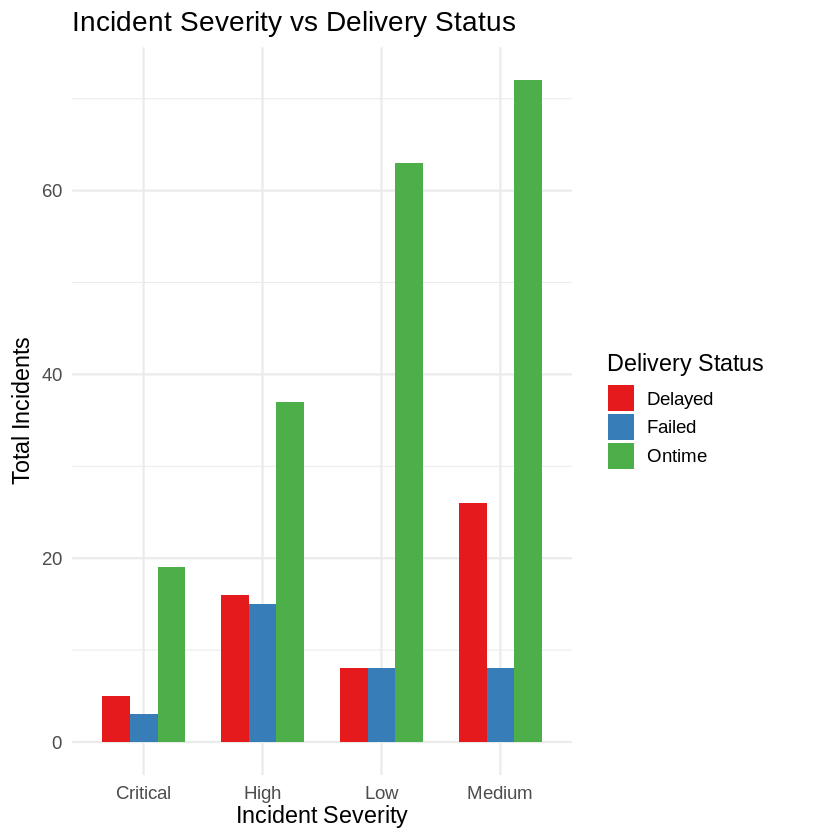

In [14]:
#-------------GRAPH 10: INCIDENT SEVERITY VS DELIVERY STATUS---------------------

incident_delivery <- DELIVERY %>%
  inner_join(INCIDENT, by = "delivery_id") %>%
  group_by(delivery_status, severity) %>%
  summarise(total_incidents = n())

ggplot(incident_delivery, aes(x = severity, y = total_incidents, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_fill_brewer(palette = "Set1") +
  labs(
    title = "Incident Severity vs Delivery Status",
    x = "Incident Severity",
    y = "Total Incidents",
    fill = "Delivery Status"
  ) +
  theme_minimal(base_size = 14)

In [15]:
#---------------------------SAVE GRAPH DATA OUTPUTS---------------------------------

write.csv(delivery_status_count, "Graph1_Delivery_Status_Distribution.csv", row.names = FALSE)
write.csv(hub_delays, "Graph2_Hub_Delayed_Deliveries.csv", row.names = FALSE)
write.csv(hub_failures, "Graph3_Hub_Failed_Deliveries.csv", row.names = FALSE)
write.csv(complaints_type, "Graph4_Complaints_By_Type.csv", row.names = FALSE)
write.csv(complaints_severity, "Graph5_Complaints_By_Severity.csv", row.names = FALSE)
write.csv(delivery_complaints, "Graph6_Delivery_Status_vs_Complaints.csv", row.names = FALSE)
write.csv(driver_problems, "Graph7_Driver_Problems.csv", row.names = FALSE)
write.csv(vehicle_failures, "Graph8_Vehicle_Failures.csv", row.names = FALSE)
write.csv(hub_volume_complaints, "Graph9_Hub_Volume_vs_Complaints.csv", row.names = FALSE)
write.csv(incident_delivery, "Graph10_Incident_Severity_vs_Delivery_Status.csv", row.names = FALSE)